In [24]:
#23.1 Tạo bản đồ Folium: 1 điểm trung tâm (UEH/trường), ≥5 địa điểm công cộng, Có marker + popup, Có zoom + bật/tắt layer
!pip -q install folium

import folium
from folium.plugins import MarkerCluster, MiniMap, Fullscreen

ueh = (10.7768, 106.6867)

places = [
    ("Ben Thanh Market", (10.7721, 106.6981), "Trung tâm thương mại - du lịch"),
    ("Tu Du Hospital", (10.7648, 106.6840), "Bệnh viện lớn gần trung tâm"),
    ("Tao Dan Park", (10.7790, 106.6923), "Không gian công cộng"),
    ("District 3 People's Committee", (10.7820, 106.6833), "Cơ quan hành chính"),
    ("Bus stop area", (10.7696, 106.6905), "Điểm trung chuyển giao thông"),
]

m = folium.Map(location=ueh, zoom_start=14, tiles="OpenStreetMap")

fg_school = folium.FeatureGroup(name="UEH").add_to(m)
folium.Marker(
    ueh,
    popup="UEH",
    tooltip="UEH",
    icon=folium.Icon(color="red", icon="university", prefix="fa"),
).add_to(fg_school)

fg_public = folium.FeatureGroup(name="Public places").add_to(m)
cluster = MarkerCluster().add_to(fg_public)

for name, coord, desc in places:
    folium.Marker(
        coord,
        popup=f"<b>{name}</b><br>{desc}",
        tooltip=name,
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(cluster)

MiniMap().add_to(m)
Fullscreen().add_to(m)
folium.LayerControl().add_to(m)

m
file_name = "23_1_map.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
#23.2 GeoPy: Geocode ≥10 địa chỉ → tọa độ, Tính khoảng cách đến 1 điểm trung tâm, Hiển thị lên bản đồ
!pip -q install geopy folium pandas

from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
import pandas as pd
import time

geolocator = Nominatim(user_agent="geo_assignment", timeout=10)
center = (10.7768, 106.6867)

address_bank = {
    "Ben Thanh Market, Ho Chi Minh City": (10.7721, 106.6981),
    "Tan Son Nhat Airport, Ho Chi Minh City": (10.8188, 106.6519),
    "University of Economics Ho Chi Minh City": (10.7768, 106.6867),
    "Independence Palace, Ho Chi Minh City": (10.7781, 106.6953),
    "Saigon Central Post Office, Ho Chi Minh City": (10.7798, 106.7008),
    "Tao Dan Park, Ho Chi Minh City": (10.7790, 106.6923),
    "Tu Du Hospital, Ho Chi Minh City": (10.7648, 106.6840),
    "District 1 People's Committee, Ho Chi Minh City": (10.7725, 106.6980),
    "Ben Thanh Bus Station, Ho Chi Minh City": (10.7729, 106.6926),
    "AEON Mall Tan Phu, Ho Chi Minh City": (10.7895, 106.6119),
}

rows = []
for addr, fallback in address_bank.items():
    loc = geolocator.geocode(addr)
    if loc is not None:
        coord = (loc.latitude, loc.longitude)
    else:
        coord = fallback
    dist_km = geodesic(center, coord).km
    rows.append([addr, coord[0], coord[1], dist_km])
    time.sleep(1)

df = pd.DataFrame(rows, columns=["address", "lat", "lon", "distance_km"])
print(df.sort_values("distance_km").to_string(index=False))

m = folium.Map(location=center, zoom_start=12)
folium.Marker(center, popup="Center", icon=folium.Icon(color="red")).add_to(m)

for _, r in df.iterrows():
    folium.Marker(
        [r["lat"], r["lon"]],
        popup=f"{r['address']}<br>{r['distance_km']:.2f} km",
        tooltip=r["address"],
        icon=folium.Icon(color="blue"),
    ).add_to(m)

m
file_name = "23_2_distance_map.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

                                        address       lat        lon  distance_km
                 Tao Dan Park, Ho Chi Minh City 10.774831 106.693272     0.751037
               Tu Du Hospital, Ho Chi Minh City 10.768727 106.685897     0.897315
          Independence Palace, Ho Chi Minh City 10.777035 106.695488     0.961485
       University of Economics Ho Chi Minh City 10.783014 106.694893     1.129298
District 1 People's Committee, Ho Chi Minh City 10.772500 106.698000     1.324245
             Ben Thanh Market, Ho Chi Minh City 10.772530 106.698037     1.326782
   Saigon Central Post Office, Ho Chi Minh City 10.779956 106.699992     1.495056
         Tan Son Nhat Airport, Ho Chi Minh City 10.817979 106.656265     5.641501
            AEON Mall Tan Phu, Ho Chi Minh City 10.800646 106.615228     8.249585
        Ben Thanh Bus Station, Ho Chi Minh City 10.877632 106.641886    12.182461


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
#23.3 Heatmap: Tạo bản đồ mật độ (khách/đơn/dân cư), Nhận diện vùng cao – thấp
!pip -q install folium numpy

import folium
from folium.plugins import HeatMap
import numpy as np

center = (10.7768, 106.6867)
np.random.seed(42)

points = []
for _ in range(200):
    lat = center[0] + np.random.normal(0, 0.01)
    lon = center[1] + np.random.normal(0, 0.01)
    points.append([lat, lon])

m = folium.Map(location=center, zoom_start=13)
HeatMap(points, radius=15, blur=10).add_to(m)

m
file_name = "23_3_heatmap.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

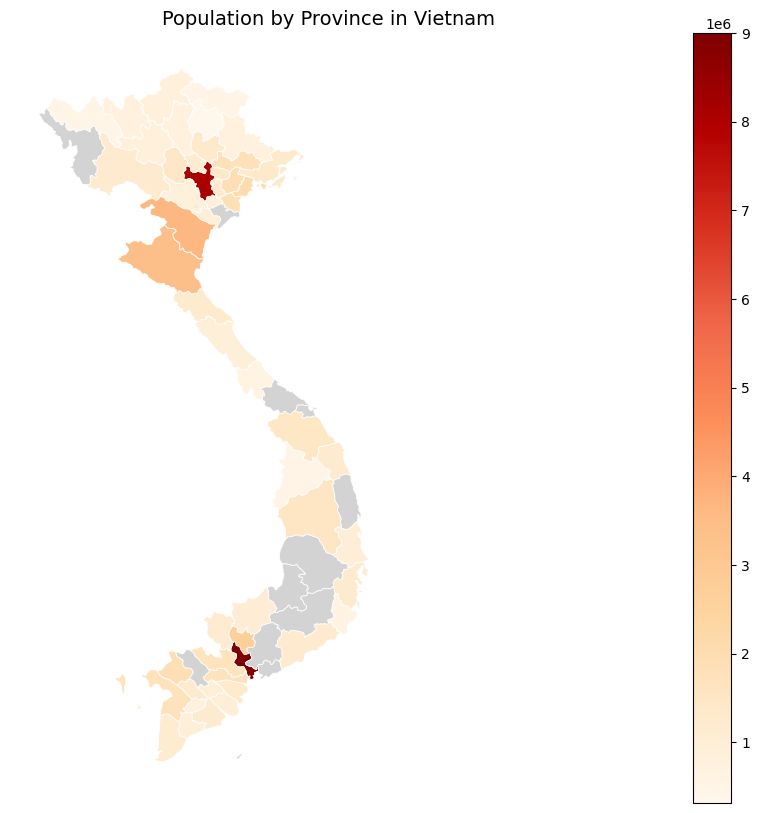

In [9]:
#23.4 GeoPandas:Đọc dữ liệu ranh giới hành chính, Ghép dữ liệu (dân số/doanh thu/đơn hàng),Vẽ choropleth. Nhận xét khác biệt khu vực
!pip -q install geopandas folium pandas

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

def norm_text(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s

geo_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/VNM/ADM1/geoBoundaries-VNM-ADM1.geojson"
gdf = gpd.read_file(geo_url)

pop = pd.read_csv("vietnam_population.csv")
gdf["key"] = gdf["shapeName"].apply(norm_text)
pop["key"] = pop["province"].apply(norm_text)

merged = gdf.merge(pop[["key", "population"]], on="key", how="left")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
merged.plot(
    column="population",
    cmap="OrRd",
    linewidth=0.6,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)
ax.set_title("Population by Province in Vietnam", fontsize=14)
ax.axis("off")
plt.show()

In [27]:
#23.5 Service area:, Vẽ vùng bán kính (3–5–10 km), Đánh giá khả năng phục vụ
!pip -q install folium geopy

import folium
from geopy.distance import geodesic

warehouse = (10.7768, 106.6867)

customers = {
    "C1": (10.7800, 106.6900),
    "C2": (10.7900, 106.7000),
    "C3": (10.7600, 106.6800),
    "C4": (10.8100, 106.7200),
    "C5": (10.7450, 106.6700),
}

m = folium.Map(location=warehouse, zoom_start=12)
folium.Marker(warehouse, popup="Warehouse", icon=folium.Icon(color="red")).add_to(m)

for name, coord in customers.items():
    d = geodesic(warehouse, coord).km
    folium.Marker(coord, popup=f"{name} - {d:.2f} km").add_to(m)

for radius, color in [(3000, "green"), (5000, "blue"), (10000, "purple")]:
    folium.Circle(warehouse, radius=radius, color=color, fill=False).add_to(m)

m
file_name = "23_5_service_area.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
#23.6 OSMnx: Tải mạng lưới đường, Vẽ bản đồ, Tính: số nút, cạnh, độ dài trung bình, Nhận xét vai trò dữ liệu giao thông
!pip -q install osmnx networkx folium

import osmnx as ox
import networkx as nx
import numpy as np
import folium

ox.settings.log_console = False
ox.settings.use_cache = True

center = (10.7768, 106.6867)
G = ox.graph_from_point(center, dist=1800, network_type="drive")

nodes = len(G.nodes)
edges = len(G.edges)
edge_lengths = [d["length"] for _, _, _, d in G.edges(keys=True, data=True)]
avg_length = np.mean(edge_lengths)

print("Nodes:", nodes)
print("Edges:", edges)
print("Average edge length:", round(avg_length, 2), "m")

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
m = folium.Map(location=center, zoom_start=14)

for _, row in edges_gdf.head(1000).iterrows():
    if row["geometry"] is not None:
        coords = [(y, x) for x, y in row["geometry"].coords]
        folium.PolyLine(coords, color="gray", weight=1, opacity=0.5).add_to(m)

m
file_name = "23_6_road_network.html"
m.save(file_name)
files.download(file_name)

Nodes: 1657
Edges: 3623
Average edge length: 81.07 m


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
#23.7 NetworkX + OSMnx: Tìm đường ngắn nhất giữa 2 điểm, So sánh Dijkstra vs A*, Hiển thị tuyến
!pip -q install osmnx networkx geopy folium

import osmnx as ox
import networkx as nx
from geopy.distance import geodesic
import folium
import time

ox.settings.log_console = False
ox.settings.use_cache = True

center = (10.7768, 106.6867)
G = ox.graph_from_point(center, dist=2500, network_type="drive")

origin = (10.7721, 106.6981)       # Ben Thanh
destination = (10.7798, 106.7008)  # Central Post Office

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

t0 = time.time()
route_d = nx.shortest_path(G, orig_node, dest_node, weight="length")
t1 = time.time()

def heuristic(u, v):
    return geodesic(
        (G.nodes[u]["y"], G.nodes[u]["x"]),
        (G.nodes[v]["y"], G.nodes[v]["x"])
    ).meters

t2 = time.time()
route_a = nx.astar_path(G, orig_node, dest_node, heuristic=heuristic, weight="length")
t3 = time.time()

len_d = nx.path_weight(G, route_d, weight="length") / 1000
len_a = nx.path_weight(G, route_a, weight="length") / 1000

print("Dijkstra:", round(len_d, 2), "km | time:", round(t1 - t0, 4), "s")
print("A*:", round(len_a, 2), "km | time:", round(t3 - t2, 4), "s")

route_coords = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in route_a]

m = folium.Map(location=center, zoom_start=14)
folium.Marker(origin, popup="Origin", icon=folium.Icon(color="red")).add_to(m)
folium.Marker(destination, popup="Destination", icon=folium.Icon(color="blue")).add_to(m)
folium.PolyLine(route_coords, color="green", weight=5, opacity=0.8).add_to(m)

m
file_name = "23_7_shortest_path.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

Dijkstra: 1.56 km | time: 0.0022 s
A*: 1.56 km | time: 0.0117 s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
#23.8 Mô phỏng gọi xe: Xe + khách (tọa độ), Gán xe tối ưu (AI/heuristic), Hiển thị kết quả trên bản đồ
!pip -q install folium geopy

import folium
from geopy.distance import geodesic
import itertools

cars = {
    "Car 1": (10.776, 106.684),
    "Car 2": (10.785, 106.690),
    "Car 3": (10.770, 106.700),
}

customers = {
    "Cust 1": (10.780, 106.695),
    "Cust 2": (10.765, 106.680),
    "Cust 3": (10.790, 106.705),
}

car_names = list(cars.keys())
cust_names = list(customers.keys())

best_total = float("inf")
best_perm = None

for perm in itertools.permutations(cust_names):
    total = 0
    for car, cust in zip(car_names, perm):
        total += geodesic(cars[car], customers[cust]).km
    if total < best_total:
        best_total = total
        best_perm = perm

print("Best assignment:")
for car, cust in zip(car_names, best_perm):
    d = geodesic(cars[car], customers[cust]).km
    print(f"{car} -> {cust} | {d:.2f} km")

m = folium.Map(location=(10.776, 106.690), zoom_start=13)

for name, coord in cars.items():
    folium.Marker(coord, popup=name, icon=folium.Icon(color="blue", icon="car", prefix="fa")).add_to(m)

for name, coord in customers.items():
    folium.Marker(coord, popup=name, icon=folium.Icon(color="red", icon="user", prefix="fa")).add_to(m)

for car, cust in zip(car_names, best_perm):
    folium.PolyLine([cars[car], customers[cust]], color="green", weight=3).add_to(m)

m
file_name = "23_8_matching.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

Best assignment:
Car 1 -> Cust 2 | 1.29 km
Car 2 -> Cust 3 | 1.73 km
Car 3 -> Cust 1 | 1.23 km


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
#23.9 Phân cụm (Clustering): Nhóm khách hàng/đơn hàng, Đề xuất vị trí kho/trạm, Trình bày trên bản đồ
!pip -q install folium scikit-learn

import pandas as pd
import folium
from sklearn.cluster import KMeans

data = pd.DataFrame({
    "lat": [10.775, 10.777, 10.780, 10.760, 10.758, 10.762, 10.790, 10.792],
    "lon": [106.700, 106.702, 106.699, 106.680, 106.682, 106.678, 106.710, 106.708]
})

X = data[["lat", "lon"]].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

m = folium.Map(location=[10.775, 106.695], zoom_start=13)
colors = ["red", "blue", "green"]

for _, r in data.iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]],
        radius=6,
        color=colors[int(r["cluster"])],
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

for i, c in enumerate(centers):
    folium.Marker([c[0], c[1]], popup=f"Centroid {i+1}", icon=folium.Icon(color="black")).add_to(m)

m
file_name = "23_9_clustering.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
#23.10 Phân tích tắc nghẽn: Dữ liệu (giả lập/mờ), Xác định vùng rủi ro, Đề xuất tuyến thay thế, Hiển thị bản đồ
!pip -q install folium scikit-learn

import pandas as pd
import folium
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame({
    "lat": [10.775, 10.777, 10.779, 10.770, 10.768],
    "lon": [106.700, 106.705, 106.695, 106.690, 106.710],
    "density": [80, 60, 90, 50, 75],
    "speed": [15, 20, 10, 30, 18],
    "incident": [3, 1, 4, 0, 2]
})

scaler = MinMaxScaler()
df[["density_n", "speed_n", "incident_n"]] = scaler.fit_transform(df[["density", "speed", "incident"]])

df["risk"] = 0.5 * df["density_n"] + 0.3 * df["incident_n"] + 0.2 * (1 - df["speed_n"])

m = folium.Map(location=[10.775, 106.700], zoom_start=13)

for _, r in df.iterrows():
    color = "red" if r["risk"] > 0.66 else "orange" if r["risk"] > 0.33 else "green"
    folium.CircleMarker(
        [r["lat"], r["lon"]],
        radius=10,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Risk: {r['risk']:.2f}"
    ).add_to(m)

folium.PolyLine(
    [(10.772, 106.691), (10.776, 106.700), (10.781, 106.707)],
    color="blue",
    weight=4,
    tooltip="Suggested alternative route"
).add_to(m)

m
file_name = "23_10_risk_map.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
#23.11 Dự đoán nhu cầu:, Xây model ML cơ bản, Dự đoán theo khu vực + thời gian, Trực quan hóa, Nhận xét điều phối nguồn lực
!pip -q install scikit-learn folium pandas numpy

import numpy as np
import pandas as pd
import folium
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

np.random.seed(42)

df = pd.DataFrame({
    "area": np.random.choice(["D1", "D3", "Binh Thanh", "Phu Nhuan"], 500),
    "hour": np.random.randint(0, 24, 500),
    "weekday": np.random.randint(0, 7, 500),
    "temperature": np.random.uniform(25, 35, 500),
    "demand": np.random.randint(10, 100, 500)
})

X = df[["area", "hour", "weekday", "temperature"]]
y = df["demand"]

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), ["area"])],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, pred), 2))

area_coords = {
    "D1": (10.775, 106.700),
    "D3": (10.780, 106.684),
    "Binh Thanh": (10.799, 106.705),
    "Phu Nhuan": (10.800, 106.676),
}

sample = pd.DataFrame({
    "area": list(area_coords.keys()),
    "hour": [18, 18, 18, 18],
    "weekday": [4, 4, 4, 4],
    "temperature": [31, 31, 31, 31]
})

sample["pred_demand"] = model.predict(sample)

m = folium.Map(location=[10.785, 106.690], zoom_start=13)
for _, r in sample.iterrows():
    lat, lon = area_coords[r["area"]]
    radius = float(r["pred_demand"]) * 2
    folium.CircleMarker(
        [lat, lon],
        radius=radius / 10,
        popup=f"{r['area']}<br>Pred: {r['pred_demand']:.1f}",
        color="red",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m
file_name = "23_11_demand_prediction.html"
m.save(file_name)
files.download(file_name)


MAE: 23.57


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
#23.12 Tối ưu giao hàng:, Nhiều kho + nhiều điểm giao, Tìm tuyến hiệu quả (heuristic/optimization), So sánh với phương án thường
!pip -q install geopy folium

from geopy.distance import geodesic
import folium

warehouses = {
    "W1": (10.776, 106.700),
    "W2": (10.790, 106.680)
}

customers = {
    "C1": (10.780, 106.710),
    "C2": (10.792, 106.685),
    "C3": (10.770, 106.690),
    "C4": (10.785, 106.720),
    "C5": (10.765, 106.675),
    "C6": (10.795, 106.700),
}

assignments = {w: {} for w in warehouses}

for cname, ccoord in customers.items():
    nearest_w = min(warehouses, key=lambda w: geodesic(warehouses[w], ccoord).km)
    assignments[nearest_w][cname] = ccoord

print("=== ASSIGNMENT RESULT ===")
for w, custs in assignments.items():
    print(w, "->", list(custs.keys()))

def nearest_neighbor(depot_name, depot_coord, cust_dict):
    route = [depot_name]
    current_coord = depot_coord
    unvisited = dict(cust_dict)
    total_dist = 0

    while unvisited:
        next_cust = min(
            unvisited,
            key=lambda c: geodesic(current_coord, unvisited[c]).km
        )
        dist = geodesic(current_coord, unvisited[next_cust]).km
        total_dist += dist

        current_coord = unvisited[next_cust]
        route.append(next_cust)
        del unvisited[next_cust]

    total_dist += geodesic(current_coord, depot_coord).km
    route.append(depot_name)

    return route, total_dist

print("\n=== ROUTE COMPARISON ===")

results = {}

for w, custs in assignments.items():
    print("\nDepot:", w)

    opt_route, opt_km = nearest_neighbor(w, warehouses[w], custs)
    print("Optimized route:", opt_route)
    print("Optimized distance:", round(opt_km, 2), "km")

    naive_names = [w] + list(custs.keys()) + [w]
    naive_coords = [warehouses[w]] + list(custs.values()) + [warehouses[w]]

    naive_km = sum(
        geodesic(naive_coords[i], naive_coords[i+1]).km
        for i in range(len(naive_coords)-1)
    )

    print("Naive route:", naive_names)
    print("Naive distance:", round(naive_km, 2), "km")

    results[w] = {
        "opt_route": opt_route,
        "opt_km": opt_km,
        "naive_km": naive_km
    }

m = folium.Map(location=[10.78, 106.69], zoom_start=13)

for w, coord in warehouses.items():
    folium.Marker(
        coord,
        popup=f"Warehouse {w}",
        icon=folium.Icon(color="green", icon="home")
    ).add_to(m)

for cname, coord in customers.items():
    folium.Marker(
        coord,
        popup=cname,
        icon=folium.Icon(color="blue")
    ).add_to(m)

colors = ["red", "purple"]

for i, (w, data) in enumerate(results.items()):
    route = data["opt_route"]

    route_coords = []
    for point in route:
        if point in warehouses:
            route_coords.append(warehouses[point])
        else:
            route_coords.append(customers[point])

    folium.PolyLine(
        route_coords,
        color=colors[i % len(colors)],
        weight=4,
        popup=f"Route {w}"
    ).add_to(m)

m
file_name = "23_12_route_map.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

=== ASSIGNMENT RESULT ===
W1 -> ['C1', 'C3', 'C4', 'C6']
W2 -> ['C2', 'C5']

=== ROUTE COMPARISON ===

Depot: W1
Optimized route: ['W1', 'C1', 'C4', 'C6', 'C3', 'W1']
Optimized distance: 9.11 km
Naive route: ['W1', 'C1', 'C3', 'C4', 'C6', 'W1']
Naive distance: 11.86 km

Depot: W2
Optimized route: ['W2', 'C2', 'C5', 'W2']
Optimized distance: 6.59 km
Naive route: ['W2', 'C2', 'C5', 'W2']
Naive distance: 6.59 km


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
#23.13 Dashboard bản đồ: Nhiều layer: điểm, vùng, tuyến, Có tương tác, Phục vụ báo cáo/quyết định
!pip -q install folium

import folium
from folium.plugins import HeatMap, MarkerCluster, MiniMap, Fullscreen

m = folium.Map(location=[10.776, 106.700], zoom_start=13)

fg_points = folium.FeatureGroup(name="Points").add_to(m)
fg_heat = folium.FeatureGroup(name="Heatmap").add_to(m)
fg_area = folium.FeatureGroup(name="Service Area").add_to(m)

cluster = MarkerCluster().add_to(fg_points)
folium.Marker([10.776, 106.700], popup="Warehouse", icon=folium.Icon(color="red")).add_to(cluster)
folium.Marker([10.780, 106.705], popup="Customer A", icon=folium.Icon(color="blue")).add_to(cluster)
folium.Marker([10.765, 106.680], popup="Customer B", icon=folium.Icon(color="blue")).add_to(cluster)

HeatMap([[10.775, 106.700], [10.777, 106.702], [10.780, 106.699]]).add_to(fg_heat)
folium.Circle([10.776, 106.700], radius=3000, color="blue", fill=False).add_to(fg_area)

MiniMap().add_to(m)
Fullscreen().add_to(m)
folium.LayerControl().add_to(m)

m
file_name = "23_13_dashboard.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
#23.14 Mô phỏng điều phối xe: Xe di chuyển theo thời gian, Cập nhật trạng thái liên tục, Hiển thị theo từng bước
!pip -q install folium

import folium
from folium.plugins import TimestampedGeoJson

center = (10.7768, 106.6867)
features = [
    {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [106.6867, 10.7768]},
        "properties": {"time": "2026-04-21T08:00:00", "popup": "Vehicle 1", "icon": "circle", "iconstyle": {"fillColor": "red", "fillOpacity": 0.8, "stroke": "true", "radius": 6}},
    },
    {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [106.6900, 10.7790]},
        "properties": {"time": "2026-04-21T08:10:00", "popup": "Vehicle 1", "icon": "circle", "iconstyle": {"fillColor": "red", "fillOpacity": 0.8, "stroke": "true", "radius": 6}},
    },
    {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [106.6950, 10.7820]},
        "properties": {"time": "2026-04-21T08:20:00", "popup": "Vehicle 1", "icon": "circle", "iconstyle": {"fillColor": "red", "fillOpacity": 0.8, "stroke": "true", "radius": 6}},
    },
    {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [106.7000, 10.7760]},
        "properties": {"time": "2026-04-21T08:30:00", "popup": "Vehicle 1", "icon": "circle", "iconstyle": {"fillColor": "red", "fillOpacity": 0.8, "stroke": "true", "radius": 6}},
    },
]

m = folium.Map(location=center, zoom_start=14)

TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="PT10M",
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY/MM/DD HH:mm",
    time_slider_drag_update=True
).add_to(m)

m
file_name = "23_14_simulation.html"
m.save(file_name)

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
#23.15 Đề xuất ứng dụng AI: Chọn bài toán (logistics/đô thị/gọi xe…). Mô tả: dữ liệu, phương pháp AI,  cách hiển thị bản đồ, giá trị thực tiễn
!pip -q install folium scikit-learn pandas numpy

import numpy as np
import pandas as pd
import folium
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

np.random.seed(42)

areas = pd.DataFrame({
    "area": ["D1", "D3", "Binh Thanh", "Phu Nhuan", "Tan Binh", "Thu Duc"],
    "lat":  [10.775, 10.780, 10.799, 10.800, 10.814, 10.850],
    "lon":  [106.700, 106.684, 106.705, 106.676, 106.651, 106.730],
})

records = []
for _, row in areas.iterrows():
    for hour in [8, 12, 18]:
        for _ in range(40):
            demand = np.random.randint(20, 100)
            temp = np.random.uniform(25, 35)
            records.append([row["area"], hour, temp, demand])

df = pd.DataFrame(records, columns=["area", "hour", "temperature", "demand"])

X = df[["area", "hour", "temperature"]]
y = df["demand"]

preprocess = ColumnTransformer(
    transformers=[("area", OneHotEncoder(handle_unknown="ignore"), ["area"])],
    remainder="passthrough"
)

model = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestRegressor(n_estimators=150, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, pred), 2))

sample = pd.DataFrame({
    "area": areas["area"],
    "hour": [18] * len(areas),
    "temperature": [31] * len(areas)
})
sample["pred_demand"] = model.predict(sample)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
areas["cluster"] = kmeans.fit_predict(areas[["lat", "lon"]])

m = folium.Map(location=[10.800, 106.700], zoom_start=12)

colors = ["red", "blue", "green"]
for _, row in areas.iterrows():
    demand_val = float(sample[sample["area"] == row["area"]]["pred_demand"].iloc[0])
    folium.CircleMarker(
        [row["lat"], row["lon"]],
        radius=max(4, demand_val / 10),
        color=colors[int(row["cluster"])],
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['area']}<br>Pred demand: {demand_val:.1f}"
    ).add_to(m)

m
file_name = "23_15_AI_logistics.html"
m.save(file_name)
files.download(file_name)

MAE: 23.87


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>